# Stage 07: Outliers + Risk Assumptions - Completed Submission

This notebook starts from the required starter workflow, generates the seeded
Stage 07 CSV under `data/raw/`, imports reusable functions with the exact
starter signatures, creates boolean outlier flags, compares three treatments,
and documents the assumptions and risks behind the results.

## Completion Map

- Required dataset: generated deterministically by the Setup cell and reloaded from `data/raw/outliers_homework.csv`.
- Required functions: `detect_outliers_iqr(series, k=1.5)` and `detect_outliers_zscore(series, threshold=3.0)`.
- Stretch treatment: `winsorize_series(series, lower=0.05, upper=0.95)`.
- Sensitivity evidence: summary table, regression table, before/after distribution figure, and residual figure.
- Reflection: one Markdown section tied directly to the observed metrics.

In [1]:
import hashlib
import inspect
import json
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

RANDOM_SEED = 17
np.random.seed(RANDOM_SEED)

REPO_ROOT = next(
    parent for parent in [Path.cwd(), *Path.cwd().parents]
    if (parent / "homework" / "homework07").exists()
)
HOMEWORK_DIR = REPO_ROOT / "homework" / "homework07"
RAW_DIR = HOMEWORK_DIR / "data" / "raw"
PROCESSED_DIR = HOMEWORK_DIR / "data" / "processed"
REPORTS_DIR = HOMEWORK_DIR / "reports"
for directory in (RAW_DIR, PROCESSED_DIR, REPORTS_DIR):
    directory.mkdir(parents=True, exist_ok=True)

sys.path.insert(0, str(HOMEWORK_DIR))
from src.outliers import (
    detect_outliers_iqr,
    detect_outliers_zscore,
    iqr_bounds,
    winsorize_series,
)

print("Homework directory:", HOMEWORK_DIR.resolve())
print("Random seed:", RANDOM_SEED)

Homework directory: C:\Users\yifunger\Documents\Codex\2026-08-18\new-chat\work\bootcamp_Yifang_Qiu\homework\homework07
Random seed: 17


## Setup - Generate the Required Dataset

The starter notebook specifies this synthetic dataset and seed. The five May
shock values are deliberately retained because this stage studies outlier
decisions. The canonical CSV is overwritten deterministically on every run so a
stale local file cannot silently change the analysis.

In [2]:
dates = pd.date_range(start="2022-01-03", end="2022-06-10", freq="B")
rng = np.random.RandomState(RANDOM_SEED)
returns = rng.normal(0, 0.01, size=len(dates))
returns[dates < "2022-05-01"] -= 0.0015

shock_values = {
    "2022-05-02": 0.1748425237194541,
    "2022-05-03": -0.16825801732486943,
    "2022-05-06": -0.19667220757153227,
    "2022-05-09": 0.21240223590614747,
    "2022-05-12": -0.178729287231294,
}
for date, value in shock_values.items():
    returns[np.where(dates == pd.to_datetime(date))[0][0]] = value

daily_return_2 = returns * 0.6 + rng.normal(0, 0.005, size=len(dates))
generated = pd.DataFrame(
    {"date": dates, "daily_return": returns, "daily_return_2": daily_return_2}
)

raw_path = RAW_DIR / "outliers_homework.csv"
generated.to_csv(raw_path, index=False)
raw_hash = hashlib.sha256(raw_path.read_bytes()).hexdigest()
print(f"Saved {len(generated)} rows to {raw_path.relative_to(REPO_ROOT)}")
print("SHA-256:", raw_hash)

Saved 115 rows to homework\homework07\data\raw\outliers_homework.csv
SHA-256: 97cf6c1eb6c1e45f2c4529098536ffebf19b22f15a7c33113abe5120595a3551


## Load and Validate the Generated CSV

The analysis deliberately reloads the saved file instead of using the in-memory
generator output. This verifies the required `data/raw/` artifact and makes the
data lineage explicit.

In [3]:
data = pd.read_csv(raw_path, parse_dates=["date"])
assert data.shape == (115, 3)
assert data.isna().sum().sum() == 0
assert data["date"].is_monotonic_increasing
assert set(data.select_dtypes(include="number").columns) == {
    "daily_return", "daily_return_2"
}
pd.DataFrame(
    {
        "rows": [len(data)],
        "columns": [data.shape[1]],
        "missing_cells": [int(data.isna().sum().sum())],
        "start_date": [data["date"].min().date()],
        "end_date": [data["date"].max().date()],
    }
)

,rows,columns,missing_cells,start_date,end_date
0,115,3,0,2022-01-03,2022-06-10


## Reusable Functions and Assumptions

The required functions live in `src/outliers.py` and are imported above. They
preserve the source index, treat missingness separately from outlier status,
validate empty/non-numeric inputs, and reject invalid thresholds. Population
standard deviation (`ddof=0`) is used for Z-scores because the generated dataset
is treated as the complete assignment sample.

In [4]:
required_functions = [
    detect_outliers_iqr,
    detect_outliers_zscore,
    winsorize_series,
]
function_contracts = pd.DataFrame(
    {
        "function": [function.__name__ for function in required_functions],
        "signature": [str(inspect.signature(function)) for function in required_functions],
        "has_docstring": [bool(inspect.getdoc(function)) for function in required_functions],
        "module": [function.__module__ for function in required_functions],
    }
)
assert function_contracts["has_docstring"].all()
function_contracts

,function,signature,has_docstring,module
0,detect_outliers_iqr,"(series: 'pd.Series', k: 'float' = 1.5) -> 'pd...",True,src.outliers
1,detect_outliers_zscore,"(series: 'pd.Series', threshold: 'float' = 3.0...",True,src.outliers
2,winsorize_series,"(series: 'pd.Series', lower: 'float' = 0.05, u...",True,src.outliers


## Detect Outliers and Create Boolean Flags

IQR with `k=1.5` is the primary robust rule. Absolute population Z-score above
`3.0` is a secondary, distribution-sensitive comparison. A disagreement is
informative: these methods encode different assumptions and should not be
treated as interchangeable labels of bad data.

In [5]:
IQR_K = 1.5
Z_THRESHOLD = 3.0
LOWER_QUANTILE = 0.05
UPPER_QUANTILE = 0.95
TARGET_COLUMN = "daily_return"

lower_fence, upper_fence = iqr_bounds(data[TARGET_COLUMN], k=IQR_K)
data["outlier_iqr"] = detect_outliers_iqr(data[TARGET_COLUMN], k=IQR_K)
data["outlier_zscore"] = detect_outliers_zscore(
    data[TARGET_COLUMN], threshold=Z_THRESHOLD
)
data["outlier_either"] = data["outlier_iqr"] | data["outlier_zscore"]
data["outlier_both"] = data["outlier_iqr"] & data["outlier_zscore"]

flag_summary = pd.DataFrame(
    {
        "method": ["IQR", "Z-score", "Either", "Both"],
        "flagged_rows": [
            int(data["outlier_iqr"].sum()),
            int(data["outlier_zscore"].sum()),
            int(data["outlier_either"].sum()),
            int(data["outlier_both"].sum()),
        ],
    }
)
flag_summary["flagged_percent"] = flag_summary["flagged_rows"] / len(data) * 100
assert data[["outlier_iqr", "outlier_zscore"]].dtypes.eq(bool).all()
flag_summary

,method,flagged_rows,flagged_percent
0,IQR,9,7.826087
1,Z-score,5,4.347826
2,Either,9,7.826087
3,Both,5,4.347826


In [6]:
flagged_observations = data.loc[
    data["outlier_either"],
    ["date", "daily_return", "daily_return_2", "outlier_iqr", "outlier_zscore"],
].sort_values("daily_return")
flagged_observations

,date,daily_return,daily_return_2,outlier_iqr,outlier_zscore
89,2022-05-06,-0.196672,-0.115209,True,True
93,2022-05-12,-0.178729,-0.100548,True,True
86,2022-05-03,-0.168258,-0.095461,True,True
87,2022-05-04,-0.033999,-0.028415,True,False
63,2022-03-31,-0.031101,-0.020710,True,False
92,2022-05-11,0.028711,0.017664,True,False
41,2022-03-01,0.031952,0.023944,True,False
85,2022-05-02,0.174843,0.112930,True,True
90,2022-05-09,0.212402,0.136536,True,True


## Visual Comparison: Original, Filtered, and Winsorized

The first panel is the requested before/after boxplot. The second preserves time
context and distinguishes IQR-only observations from shocks flagged by both
methods. The plots show statistical treatment choices; they do not establish
that any flagged observation is erroneous.

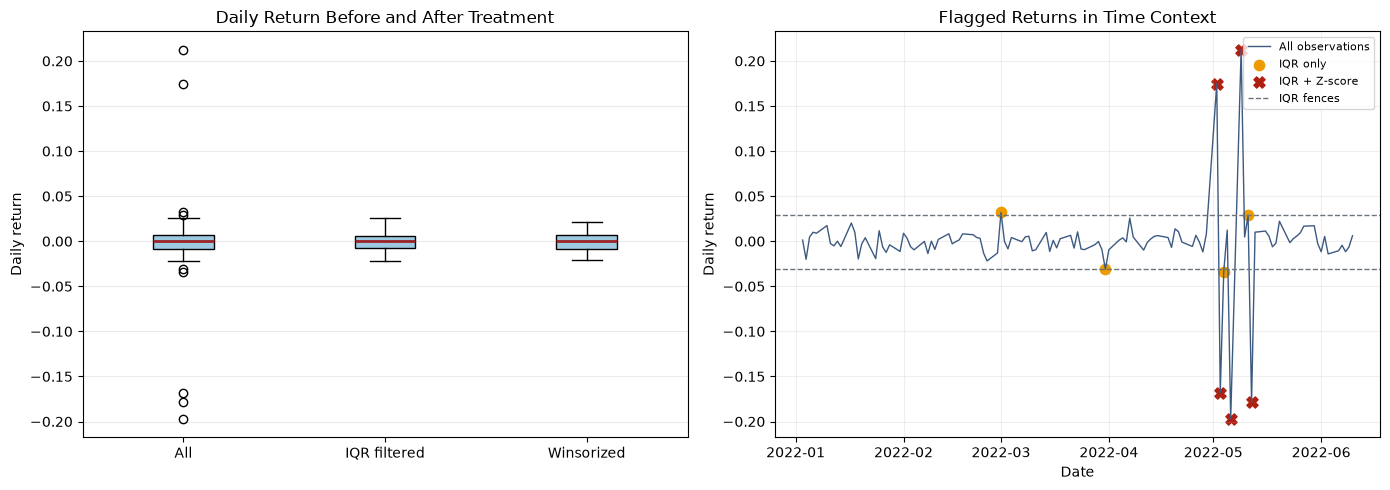

In [7]:
filtered_data = data.loc[~data["outlier_iqr"]].copy()
winsorized_data = data.copy()
winsorized_data["daily_return"] = winsorize_series(
    winsorized_data["daily_return"], lower=LOWER_QUANTILE, upper=UPPER_QUANTILE
)
winsorized_data["daily_return_2"] = winsorize_series(
    winsorized_data["daily_return_2"], lower=LOWER_QUANTILE, upper=UPPER_QUANTILE
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].boxplot(
    [data["daily_return"], filtered_data["daily_return"], winsorized_data["daily_return"]],
    tick_labels=["All", "IQR filtered", "Winsorized"],
    patch_artist=True,
    boxprops={"facecolor": "#9ecae1"},
    medianprops={"color": "#9b2226", "linewidth": 2},
)
axes[0].set_title("Daily Return Before and After Treatment")
axes[0].set_ylabel("Daily return")
axes[0].grid(axis="y", alpha=0.25)

axes[1].plot(data["date"], data["daily_return"], color="#3d5a80", linewidth=1, label="All observations")
iqr_only = data[data["outlier_iqr"] & ~data["outlier_zscore"]]
both = data[data["outlier_both"]]
axes[1].scatter(iqr_only["date"], iqr_only["daily_return"], color="#ee9b00", s=55, label="IQR only")
axes[1].scatter(both["date"], both["daily_return"], color="#ae2012", s=65, marker="X", label="IQR + Z-score")
axes[1].axhline(lower_fence, color="#6c757d", linestyle="--", linewidth=1, label="IQR fences")
axes[1].axhline(upper_fence, color="#6c757d", linestyle="--", linewidth=1)
axes[1].set_title("Flagged Returns in Time Context")
axes[1].set_xlabel("Date")
axes[1].set_ylabel("Daily return")
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.2)

fig.tight_layout()
distribution_plot_path = REPORTS_DIR / "outlier_treatment_comparison.png"
fig.savefig(distribution_plot_path, dpi=160, bbox_inches="tight")
plt.show()

## Sensitivity Analysis

The summary table satisfies the required mean/median/standard-deviation
comparison. The regression is an additional descriptive sensitivity test:
`daily_return_2` is regressed on `daily_return` for all, IQR-filtered, and
winsorized variants. It is in-sample, not causal, predictive, or investment
advice. Winsorization is applied to both modeled return columns so the treatment
is internally consistent.

In [8]:
variants = {
    "all_data": data,
    "filtered_iqr": filtered_data,
    "winsorized_5_95": winsorized_data,
}

summary_rows = []
for treatment, frame in variants.items():
    series = frame["daily_return"]
    summary_rows.append(
        {
            "treatment": treatment,
            "observations": len(frame),
            "mean": series.mean(),
            "median": series.median(),
            "std": series.std(ddof=1),
            "minimum": series.min(),
            "maximum": series.max(),
        }
    )
summary_sensitivity = pd.DataFrame(summary_rows)
summary_sensitivity

,treatment,observations,mean,median,std,minimum,maximum
0,all_data,115,-0.001434,-0.000187,0.040579,-0.196672,0.212402
1,filtered_iqr,106,-0.000039,-0.000100,0.009443,-0.021860,0.025708
2,winsorized_5_95,115,-0.000251,-0.000187,0.010623,-0.020590,0.020797


In [9]:
regression_rows = []
residual_frames = {}
for treatment, frame in variants.items():
    X = frame[["daily_return"]].to_numpy()
    y = frame["daily_return_2"].to_numpy()
    model = LinearRegression().fit(X, y)
    predicted = model.predict(X)
    residuals = y - predicted
    regression_rows.append(
        {
            "treatment": treatment,
            "observations": len(frame),
            "slope": model.coef_[0],
            "intercept": model.intercept_,
            "r2": r2_score(y, predicted),
            "mae": mean_absolute_error(y, predicted),
            "residual_std": residuals.std(ddof=1),
        }
    )
    residual_frames[treatment] = pd.DataFrame(
        {"fitted": predicted, "residual": residuals}
    )

regression_sensitivity = pd.DataFrame(regression_rows)
regression_sensitivity

,treatment,observations,slope,intercept,r2,mae,residual_std
0,all_data,115,0.605869,0.000201,0.961859,0.003951,0.004896
1,filtered_iqr,106,0.589679,-0.000049,0.573566,0.003851,0.004801
2,winsorized_5_95,115,0.649705,-0.000017,0.689444,0.003741,0.004632


## Stretch: Residual Influence

Residual plots show whether treatment changes model error dispersion or leaves
structure around zero. Metrics are interpreted jointly because R-squared can
fall after removing influential but genuine shared shocks.

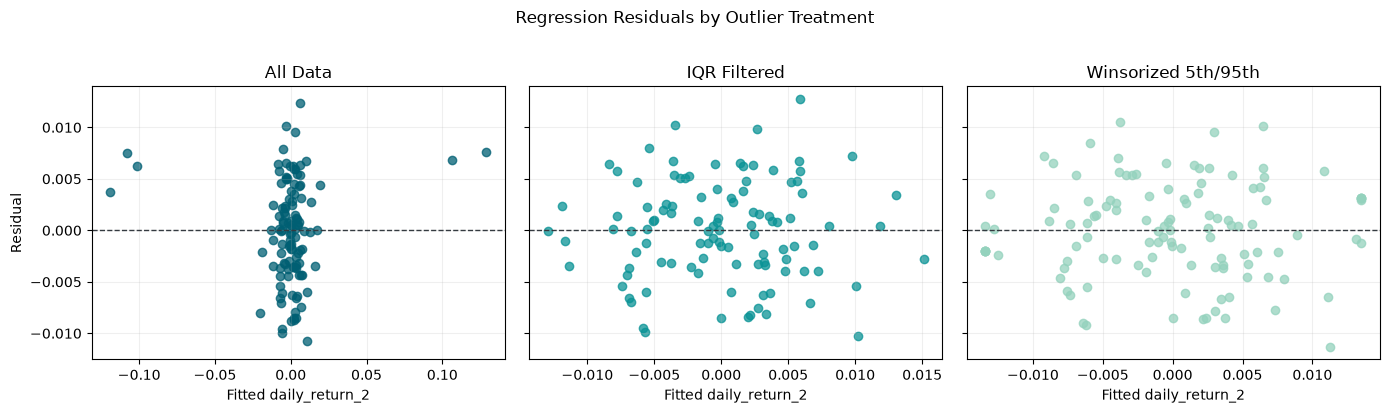

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
colors = ["#005f73", "#0a9396", "#94d2bd"]
display_titles = {
    "all_data": "All Data",
    "filtered_iqr": "IQR Filtered",
    "winsorized_5_95": "Winsorized 5th/95th",
}
for axis, (treatment, residual_frame), color in zip(axes, residual_frames.items(), colors):
    axis.scatter(residual_frame["fitted"], residual_frame["residual"], alpha=0.75, color=color)
    axis.axhline(0, color="#343a40", linestyle="--", linewidth=1)
    axis.set_title(display_titles[treatment])
    axis.set_xlabel("Fitted daily_return_2")
    axis.grid(alpha=0.2)
axes[0].set_ylabel("Residual")
fig.suptitle("Regression Residuals by Outlier Treatment", y=1.02)
fig.tight_layout()
residual_plot_path = REPORTS_DIR / "regression_residual_sensitivity.png"
fig.savefig(residual_plot_path, dpi=160, bbox_inches="tight")
plt.show()

## Save and Reload Reproducible Outputs

Canonical filenames make reruns idempotent. Metadata records the source hash,
parameters, decisions, validation evidence, and output paths.

In [11]:
flags_path = PROCESSED_DIR / "outlier_flags.csv"
summary_path = PROCESSED_DIR / "sensitivity_summary.csv"
regression_path = PROCESSED_DIR / "regression_sensitivity.csv"
metadata_path = PROCESSED_DIR / "analysis_metadata.json"

data.to_csv(flags_path, index=False)
summary_sensitivity.to_csv(summary_path, index=False)
regression_sensitivity.to_csv(regression_path, index=False)

metadata = {
    "source_file": raw_path.relative_to(REPO_ROOT).as_posix(),
    "source_sha256": raw_hash,
    "random_seed": RANDOM_SEED,
    "required_functions": [function.__name__ for function in required_functions],
    "parameters": {
        "iqr_k": IQR_K,
        "zscore_threshold": Z_THRESHOLD,
        "winsor_lower": LOWER_QUANTILE,
        "winsor_upper": UPPER_QUANTILE,
    },
    "flag_counts": {
        "iqr": int(data["outlier_iqr"].sum()),
        "zscore": int(data["outlier_zscore"].sum()),
        "either": int(data["outlier_either"].sum()),
        "both": int(data["outlier_both"].sum()),
    },
    "validation": {
        "raw_rows": int(len(data)),
        "no_missing_values": bool(data.isna().sum().sum() == 0),
        "boolean_flags": bool(data[["outlier_iqr", "outlier_zscore"]].dtypes.eq(bool).all()),
        "three_treatments": bool(len(summary_sensitivity) == 3),
    },
    "outputs": {
        "flags": flags_path.relative_to(REPO_ROOT).as_posix(),
        "summary": summary_path.relative_to(REPO_ROOT).as_posix(),
        "regression": regression_path.relative_to(REPO_ROOT).as_posix(),
        "distribution_plot": distribution_plot_path.relative_to(REPO_ROOT).as_posix(),
        "residual_plot": residual_plot_path.relative_to(REPO_ROOT).as_posix(),
    },
}
metadata_path.write_text(json.dumps(metadata, indent=2), encoding="utf-8")

reloaded_flags = pd.read_csv(flags_path)
reloaded_summary = pd.read_csv(summary_path)
reloaded_regression = pd.read_csv(regression_path)
assert reloaded_flags.shape == data.shape
assert reloaded_summary["treatment"].tolist() == list(variants)
assert reloaded_regression["treatment"].tolist() == list(variants)
assert metadata["validation"] == {
    "raw_rows": 115,
    "no_missing_values": True,
    "boolean_flags": True,
    "three_treatments": True,
}
print("Saved and reloaded:", flags_path.name, summary_path.name, regression_path.name)
print("Metadata:", metadata_path.name)

Saved and reloaded: outlier_flags.csv sensitivity_summary.csv regression_sensitivity.csv
Metadata: analysis_metadata.json


## Reflection: Assumptions, Observed Impact, and Risk

**Methods and thresholds.** I used Tukey IQR with `k=1.5` as the primary rule
because quartiles are less distorted by extreme returns than the mean and
standard deviation. I used absolute population Z-score above `3.0` as a
secondary comparison and 5th/95th percentile winsorization as a reversible
sensitivity treatment. These are conventional exploratory thresholds, not
universal definitions of error.

**Assumptions.** The seeded 115-row dataset is treated as the complete assignment
sample, has no missing values, and contains five deliberately injected May
shocks. IQR assumes the central 50% gives a useful reference range; Z-score is
more dependent on approximate distributional symmetry. The regression assumes a
linear association between the two generated return columns and is evaluated
in-sample only.

**Observed impact.** IQR flagged 9 rows
(7.8%), while Z-score flagged
5 (4.3%);
all Z-score flags were also IQR flags. IQR filtering reduced sample standard
deviation from 0.0406 to 0.0094 (76.7% lower),
while winsorization reduced it to 0.0106 (73.8% lower).
Regression R-squared changed from 0.962 for all data to
0.574 after IQR filtering and
0.689 after winsorization. The lower filtered R-squared
shows that the shared shocks carry genuine correlation; removal did not simply
make the model “better.”

**Risks and decision.** If the thresholds are wrong, filtering can erase the
rare stress events most relevant to risk management, while leaving them in can
dominate averages and fitted relationships. Winsorization retains rows but
alters economic magnitudes. I therefore preserve the raw data and boolean flags,
report all three treatments, and make no causal, predictive, or trading claim.
For real decisions I would use a longer time series, investigate data lineage,
fit thresholds on training data only, and obtain stakeholder agreement before
any irreversible exclusion.

## Completion Checklist

- [x] Starter-generated CSV saved under `data/raw/` with seeded randomness.
- [x] Required parameterized functions with complete docstrings.
- [x] Boolean IQR and Z-score flags applied to a numeric column.
- [x] Three-treatment sensitivity tables.
- [x] Two figures, including a before/after boxplot and residual analysis.
- [x] Reflection tied to assumptions, observed metrics, and decision risk.
- [x] Canonical outputs saved, reloaded, and validated.